In [156]:
# plotting survival rate by features

In [157]:
#analysis of who was travelling alone and with family

import pandas as pd

df = pd.read_csv('/content/Titanic-Dataset.csv')

# Create family-related columns

df['FamilySize'] = df['SibSp'] + df['Parch']

df['IsAlone'] = df['FamilySize'].apply(
    lambda x: 'Alone' if x == 0 else 'With Family'
)

# Extract surname (family name)
df['Surname'] = df['Name'].str.split(',').str[0]


# People traveling alone
alone = df[df['IsAlone'] == 'Alone']

# print("\n People Traveling Alone ")
# print(alone[['PassengerId', 'Name', 'Pclass', 'Survived']].head())


# People traveling with family
with_family = df[df['IsAlone'] == 'With Family']

# print("\nPeople Traveling With Family")
# print(with_family[['PassengerId', 'Name', 'Surname', 'Pclass', 'FamilySize', 'Survived']].head())


# Who was with whom (group by family) for 5 families
family_groups = df[df['FamilySize'] > 0].groupby('Surname')
print("\n Family Groups (Who was with whom) - First 5 families only")

count = 0

for surname, group in family_groups:
    if len(group) > 1:  # only real families
        print(f"\nFamily: {surname}")
        print(group[['Name', 'Pclass', 'FamilySize', 'Survived']])

        count += 1
        if count == 5:
            break

# Survival summary

print("\n Survival Summary ")
print(df.groupby('IsAlone')['Survived'].agg(['count', 'sum', 'mean']))


 Family Groups (Who was with whom) - First 5 families only

Family: Abbott
                                 Name  Pclass  FamilySize  Survived
279  Abbott, Mrs. Stanton (Rosa Hunt)       3           2         1
746       Abbott, Mr. Rossmore Edward       3           2         0

Family: Abelson
                                      Name  Pclass  FamilySize  Survived
308                    Abelson, Mr. Samuel       2           1         0
874  Abelson, Mrs. Samuel (Hannah Wizosky)       2           1         1

Family: Allison
                                                Name  Pclass  FamilySize  \
297                     Allison, Miss. Helen Loraine       1           3   
305                   Allison, Master. Hudson Trevor       1           3   
498  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)       1           3   

     Survived  
297         0  
305         1  
498         0  

Family: Andersson
                                                  Name  Pclass  FamilySize  \
1

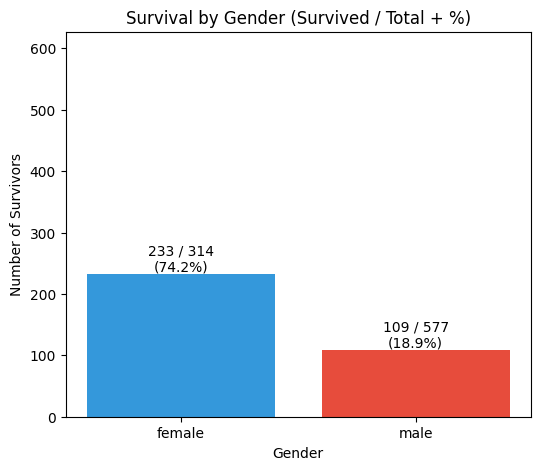

In [158]:
#survival rate by gender

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Titanic-Dataset.csv')

summary = df.groupby('Sex')['Survived'].agg(['sum', 'count'])
summary.columns = ['Survived', 'Total']

# Create percentage label
summary['Percent'] = (summary['Survived'] / summary['Total'] * 100).round(1)

summary['Label'] = summary['Survived'].astype(str) + " / " + summary['Total'].astype(str) + \
                   "\n(" + summary['Percent'].astype(str) + "%)"

plt.figure(figsize=(6,5))

bars = plt.bar(
    summary.index,
    summary['Survived'],
    color=['#3498db', '#e74c3c']
)

#add labels
for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        summary['Label'].iloc[i],
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Survival by Gender (Survived / Total + %)')
plt.xlabel('Gender')
plt.ylabel('Number of Survivors')
plt.ylim(0, max(summary['Total']) + 50)

plt.show()

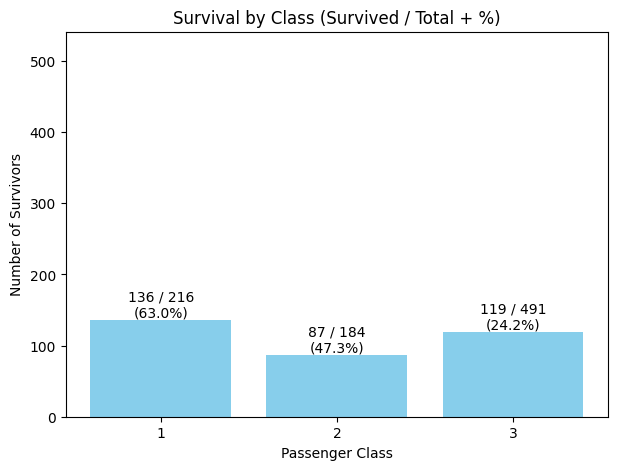

In [159]:
#simple understanding plotting
#survival rate by Pclass
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Titanic-Dataset.csv')

summary = df.groupby('Pclass')['Survived'].agg(['sum', 'count'])
summary.columns = ['Survived', 'Total']

summary['Percent'] = (summary['Survived'] / summary['Total'] * 100).round(1)

# Label = Survived / Total + Percentage
summary['Label'] = (
    summary['Survived'].astype(str) + " / " +
    summary['Total'].astype(str) +
    "\n(" + summary['Percent'].astype(str) + "%)"
)

plt.figure(figsize=(7,5))

bars = plt.bar(
    summary.index.astype(str),
    summary['Survived'],
    color='skyblue'
)

for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        summary['Label'].iloc[i],
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Survival by Class (Survived / Total + %)')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Survivors')
plt.ylim(0, max(summary['Total']) + 50)

plt.show()


=== Survival by Age Group ===
             Survived  Total  Not Survived  Survival %
AgeGroup                                              
Child              40     69            29        58.0
Teen               30     70            40        42.9
Young Adult       137    358           221        38.3
Adult              78    195           117        40.0
Old Age             5     22            17        22.7


/tmp/ipykernel_12951/500083436.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = df.groupby('AgeGroup')['Survived'].agg(['sum', 'count'])


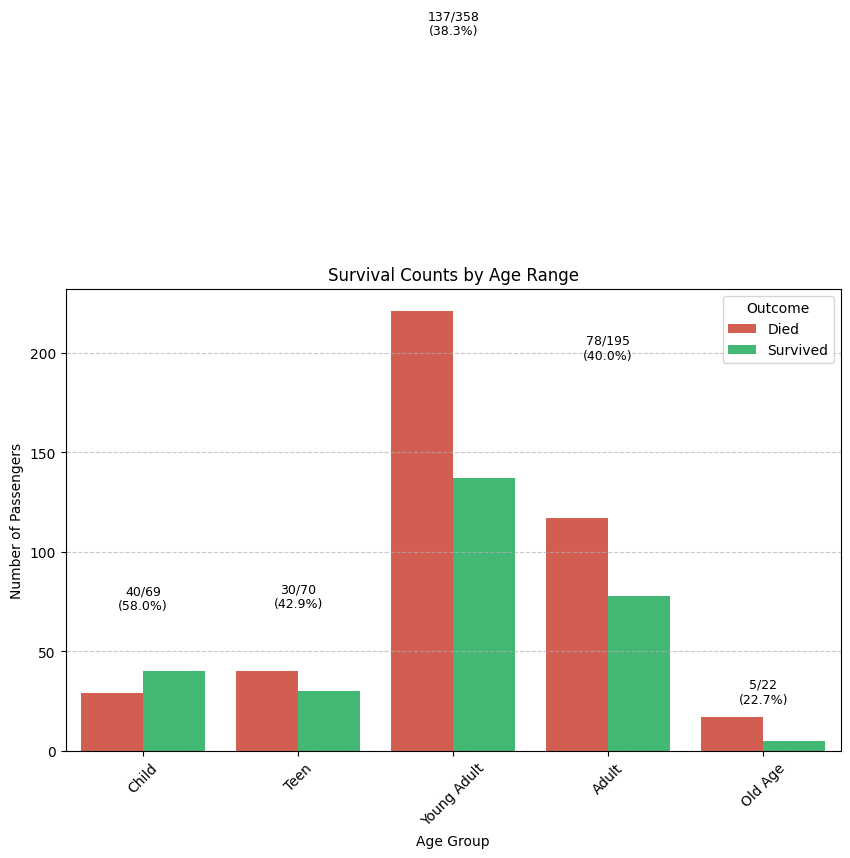

In [160]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Titanic-Dataset.csv')

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Old Age']
)

age_summary = df.groupby('AgeGroup')['Survived'].agg(['sum', 'count'])
age_summary.columns = ['Survived', 'Total']

age_summary['Not Survived'] = age_summary['Total'] - age_summary['Survived']
age_summary['Survival %'] = (age_summary['Survived'] / age_summary['Total'] * 100).round(1)

print("\n=== Survival by Age Group ===")
print(age_summary)

plt.figure(figsize=(10,6))

sns.countplot(
    x='AgeGroup',
    hue='Survived',
    data=df,
    palette={0: "#e74c3c", 1: "#2ecc71"}
)

plt.title('Survival Counts by Age Range')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=45)

plt.legend(title='Outcome', labels=['Died', 'Survived'])
plt.grid(axis='y', linestyle='--', alpha=0.7)


for i, row in enumerate(age_summary.itertuples()):
    plt.text(
        i,
        row.Total + 2,
        f"{row.Survived}/{row.Total}\n({row._4}%)",
        ha='center',
        fontsize=9
    )

plt.show()

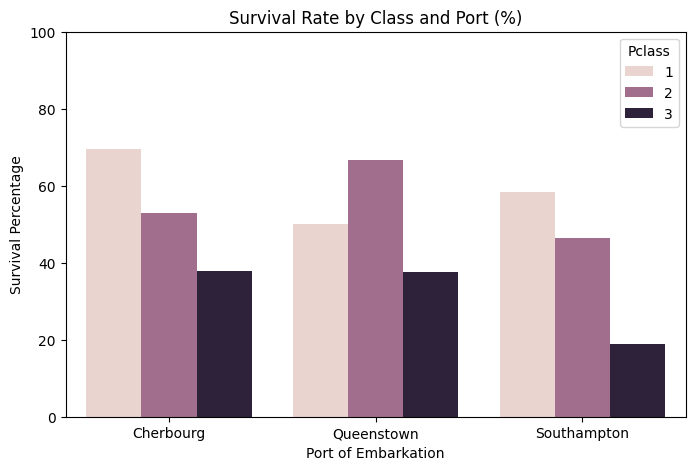

In [161]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Titanic-Dataset.csv')

# Map port codes to names
df['Embarked'] = df['Embarked'].map({
    'C': 'Cherbourg',
    'Q': 'Queenstown',
    'S': 'Southampton'
})

# Create combined survival rate
combo_rate = df.groupby(['Pclass', 'Embarked'])['Survived'].mean() * 100
combo_rate = combo_rate.reset_index()

# Plot
plt.figure(figsize=(8,5))

sns.barplot(
    x='Embarked',
    y='Survived',
    hue='Pclass',
    data=combo_rate
)

plt.title('Survival Rate by Class and Port (%)')
plt.xlabel('Port of Embarkation')
plt.ylabel('Survival Percentage')

plt.ylim(0, 100)

plt.show()

/tmp/ipykernel_12951/3771459704.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fare_summary = df.groupby('FareGroup')['Survived'].agg(['sum', 'count'])



=== Survival by Fare Group ===
                  Survived  Total  Survival %
FareGroup                                    
Low (0-10)              66    321        20.6
Medium (10-30)         139    321        43.3
High (30-100)           97    181        53.6
Very High (100+)        39     53        73.6


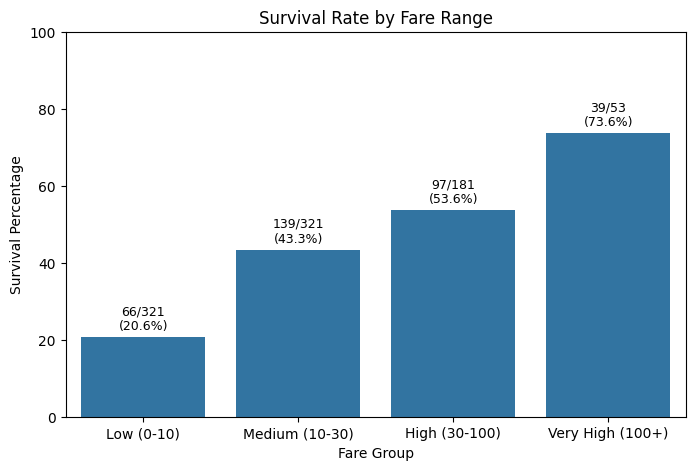

In [162]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Titanic-Dataset.csv')

df['FareGroup'] = pd.cut(
    df['Fare'],
    bins=[0, 10, 30, 100, 600],
    labels=['Low (0-10)', 'Medium (10-30)', 'High (30-100)', 'Very High (100+)']
)

# Survival Summary (Count + Percentage)

fare_summary = df.groupby('FareGroup')['Survived'].agg(['sum', 'count'])
fare_summary.columns = ['Survived', 'Total']

fare_summary['Survival %'] = (fare_summary['Survived'] / fare_summary['Total'] * 100).round(1)

print("\n=== Survival by Fare Group ===")
print(fare_summary)

fare_rate = fare_summary['Survival %']

plt.figure(figsize=(8,5))

sns.barplot(x=fare_rate.index, y=fare_rate.values)

plt.title('Survival Rate by Fare Range')
plt.xlabel('Fare Group')
plt.ylabel('Survival Percentage')

plt.ylim(0, 100)

#  Add labels-> "Survived / Total ( % )"

for i, row in enumerate(fare_summary.itertuples()):
    plt.text(
        i,
        row._3 + 2,
        f"{row.Survived}/{row.Total}\n({row._3}%)",
        ha='center',
        fontsize=9
    )

plt.show()

In [163]:
from IPython.testing import test
import pandas as pd
import numpy as np

train_df=pd.read_csv('train.csv')
test_df=pd.read_csv('test.csv')

train_df.groupby('Embarked')['Survived'].mean()

train_df['Embarked'] = train_df['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

train_df.groupby('Embarked')['Survived'].mean()

train_df.isnull().sum() #age=177,cabin=687, embarked=2
(train_df.isnull().sum() / len(train_df)) * 100

train_df.drop('Cabin', axis=1, inplace=True)
test_df.drop('Cabin', axis=1, inplace=True)

train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())


print(train_df)
train_df['Age'].isnull().sum()
print("Median Age:", train_df['Age'].median()) #28.0


     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 